<a href="https://colab.research.google.com/github/HimanshuRa0/Deep-learning/blob/main/EXP_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 16: Using LSTM to Predict Future Weather of a City Using Weather Data from Several Other Cities

**Language:** Python  
**Estimated Time:** 1 hour

## Aim
To use an **LSTM (Long Short-Term Memory)** neural network to predict the future temperature of one target city using historical weather data from several other cities.

## Learning Outcomes
- Understand time-series prediction with LSTM
- Use weather data from multiple cities as input features
- Prepare sequential data for deep learning
- Train and evaluate an LSTM model
- Predict future weather values for a target city

## Suggested Dataset Format
Use a CSV file such as `multi_city_weather.csv` with columns like:

- `date`
- `city_A_temp`
- `city_B_temp`
- `city_C_temp`
- `city_D_temp`
- `target_city_temp`

If you do not have a dataset, this notebook also creates a **sample synthetic dataset** so the experiment can run end-to-end.


In [1]:
# Install if needed (run once)
# !pip install numpy pandas matplotlib scikit-learn tensorflow


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

np.random.seed(42)


In [3]:
# Option A: Load your own dataset
# Uncomment and edit the filename if you already have weather data.
# df = pd.read_csv("multi_city_weather.csv", parse_dates=["date"])

# Option B: Create a sample synthetic multi-city weather dataset
days = 500
dates = pd.date_range(start="2022-01-01", periods=days, freq="D")

base = 25 + 8*np.sin(np.linspace(0, 12*np.pi, days))
city_A = base + np.random.normal(0, 1.0, days)
city_B = base + 1.5*np.sin(np.linspace(0, 8*np.pi, days)) + np.random.normal(0, 1.2, days)
city_C = base - 1.0*np.cos(np.linspace(0, 10*np.pi, days)) + np.random.normal(0, 1.1, days)
city_D = base + 0.5*np.sin(np.linspace(0, 15*np.pi, days)) + np.random.normal(0, 0.9, days)

# Target city temperature depends partly on other cities + its own seasonal pattern
target_city_temp = (
    0.30*city_A + 0.25*city_B + 0.20*city_C + 0.15*city_D
    + 2*np.sin(np.linspace(0, 6*np.pi, days))
    + np.random.normal(0, 0.8, days)
)

df = pd.DataFrame({
    "date": dates,
    "city_A_temp": city_A,
    "city_B_temp": city_B,
    "city_C_temp": city_C,
    "city_D_temp": city_D,
    "target_city_temp": target_city_temp
})

df.head()


,date,city_A_temp,city_B_temp,city_C_temp,city_D_temp,target_city_temp
0,2022-01-01,25.496714,26.111413,25.539291,25.700525,22.599662
1,2022-01-02,25.465555,27.970637,25.622898,25.154901,23.490057
2,2022-01-03,26.851883,24.676757,25.277705,25.561692,22.631568
3,2022-01-04,28.320730,27.699050,25.103853,26.934430,24.461710
4,2022-01-05,27.146796,26.900335,27.180537,27.412196,23.203216


In [4]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              500 non-null    datetime64[ns]
 1   city_A_temp       500 non-null    float64       
 2   city_B_temp       500 non-null    float64       
 3   city_C_temp       500 non-null    float64       
 4   city_D_temp       500 non-null    float64       
 5   target_city_temp  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 23.6 KB


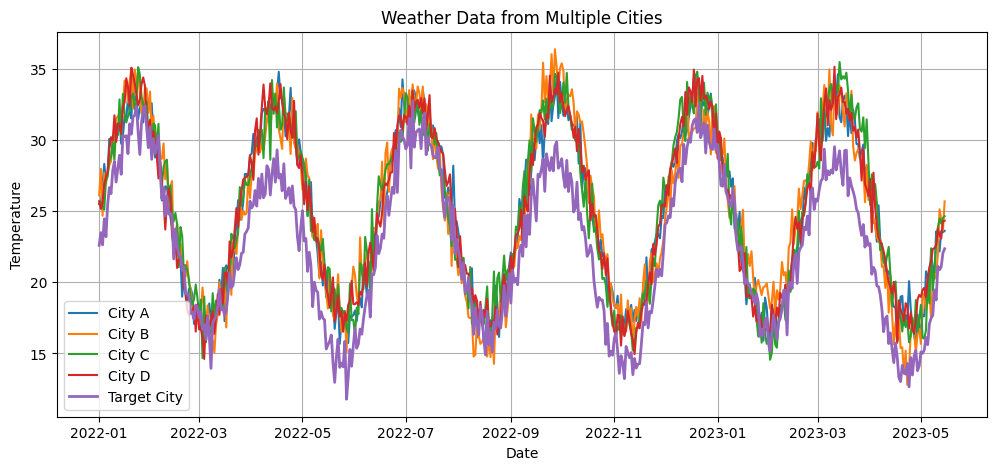

In [5]:
# Plot temperature trends
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["city_A_temp"], label="City A")
plt.plot(df["date"], df["city_B_temp"], label="City B")
plt.plot(df["date"], df["city_C_temp"], label="City C")
plt.plot(df["date"], df["city_D_temp"], label="City D")
plt.plot(df["date"], df["target_city_temp"], label="Target City", linewidth=2)
plt.title("Weather Data from Multiple Cities")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


## Feature Selection

We will use weather values from several cities as input and the **target city temperature** as the value to predict.


In [6]:
feature_cols = ["city_A_temp", "city_B_temp", "city_C_temp", "city_D_temp", "target_city_temp"]
data = df[feature_cols].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data[:5]


array([[0.52295283, 0.56474047, 0.52462512, 0.53983701, 0.51540792],
       [0.52135359, 0.64351447, 0.52861989, 0.51326933, 0.55782906],
       [0.59250796, 0.50395512, 0.51212647, 0.53307691, 0.51692803],
       [0.66789767, 0.63200749, 0.50381976, 0.59991867, 0.60412158],
       [0.60764458, 0.59816654, 0.60304435, 0.62318218, 0.5441631 ]])

## Create Sequences for LSTM

LSTM expects 3D input:
- samples
- time steps
- features

We will use the previous **30 days** to predict the next day's target city temperature.


In [7]:
def create_sequences(dataset, look_back=30, target_index=4):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, :])   # all features for past look_back days
        y.append(dataset[i, target_index])    # target city's next-day temperature
    return np.array(X), np.array(y)

look_back = 30
X, y = create_sequences(scaled_data, look_back=look_back, target_index=4)

print("X shape:", X.shape)  # (samples, time_steps, features)
print("y shape:", y.shape)


X shape: (470, 30, 5)
y shape: (470,)


In [8]:
# Train-test split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


Train samples: 376
Test samples: 94


## Build the LSTM Model

In [9]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0731 - val_loss: 0.0065
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0259 - val_loss: 0.0037
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0160 - val_loss: 0.0074
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0104 - val_loss: 0.0039
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0103 - val_loss: 0.0022
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0084 - val_loss: 0.0021
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0087 - val_loss: 0.0041
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0069 - val_loss: 0.0020
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0079 - val_loss: 0.0033
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0088 - val_loss: 0.0023
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0086 - val_loss: 0.0035
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.

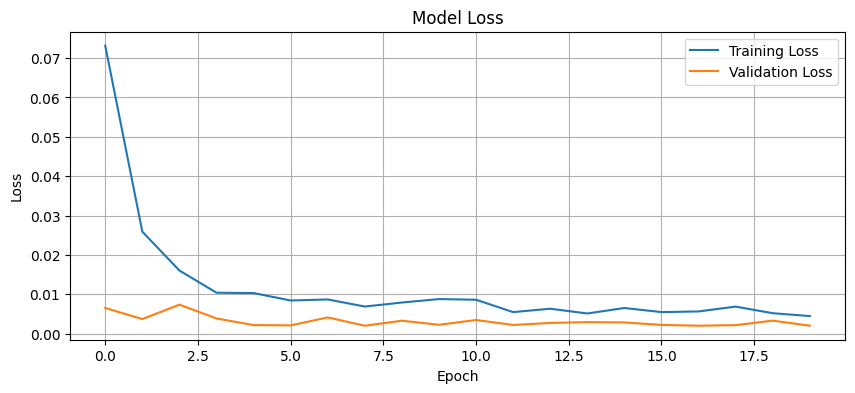

In [11]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Make Predictions and Convert Back to Real Temperatures

In [12]:
y_pred = model.predict(X_test)

# To inverse transform, rebuild arrays with same number of features
dummy_pred = np.zeros((len(y_pred), len(feature_cols)))
dummy_true = np.zeros((len(y_test), len(feature_cols)))

dummy_pred[:, 4] = y_pred.flatten()
dummy_true[:, 4] = y_test.flatten()

y_pred_actual = scaler.inverse_transform(dummy_pred)[:, 4]
y_test_actual = scaler.inverse_transform(dummy_true)[:, 4]

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("RMSE:", round(rmse, 3))
print("MAE :", round(mae, 3))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step
RMSE: 1.069
MAE : 0.888


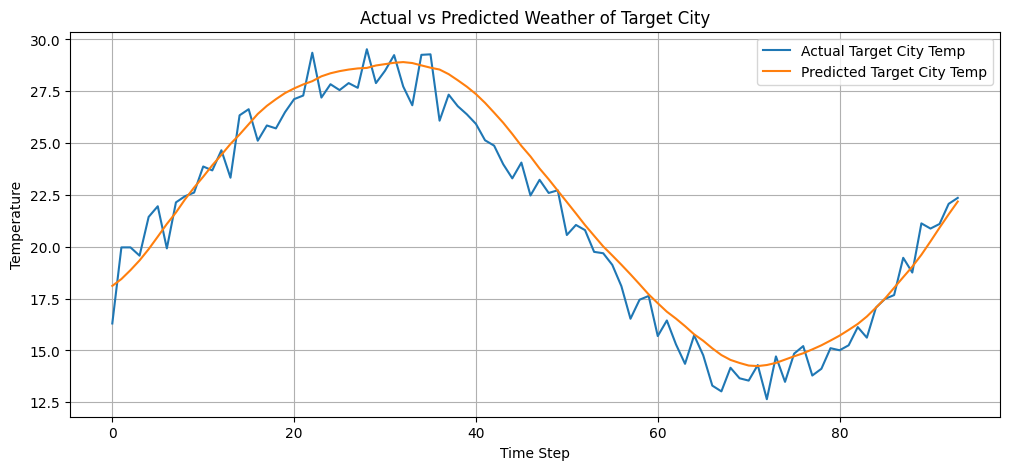

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Target City Temp")
plt.plot(y_pred_actual, label="Predicted Target City Temp")
plt.title("Actual vs Predicted Weather of Target City")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


## Predict the Next Day Weather

Use the latest 30-day window to predict the next day's target city temperature.


In [14]:
last_sequence = scaled_data[-look_back:]
last_sequence = np.expand_dims(last_sequence, axis=0)

next_day_scaled = model.predict(last_sequence)

dummy_next = np.zeros((1, len(feature_cols)))
dummy_next[:, 4] = next_day_scaled.flatten()

next_day_temp = scaler.inverse_transform(dummy_next)[:, 4][0]
print("Predicted next day temperature for target city:", round(next_day_temp, 2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted next day temperature for target city: 22.76


## Conclusion

An LSTM model was implemented to predict the future weather of a target city using weather data from several other cities.  
The notebook demonstrated:
- sequence creation for time-series forecasting,
- training an LSTM model,
- evaluating prediction accuracy,
- and forecasting the next day's temperature.

You can replace the synthetic dataset with a real multi-city weather dataset for more realistic results.
